In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from datetime import date
import seaborn as sns


In [4]:
df = pd.read_csv('Superstore.csv',encoding='latin')
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


BASIC EDA

In [5]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 21)

In [7]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'],errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')

In [11]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Visualizations

In [13]:
TotalSales = df.groupby('Category')['Sales'].sum()
TotalProfit = df.groupby('Category')['Profit'].sum()

In [14]:
print(TotalProfit)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


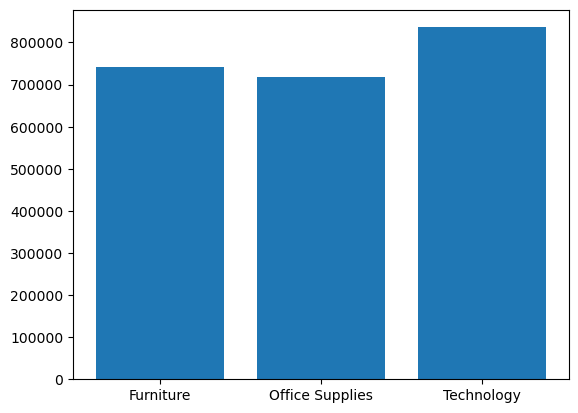

In [16]:
plt.bar(x=df['Category'].unique(),height=TotalSales)
plt.show()

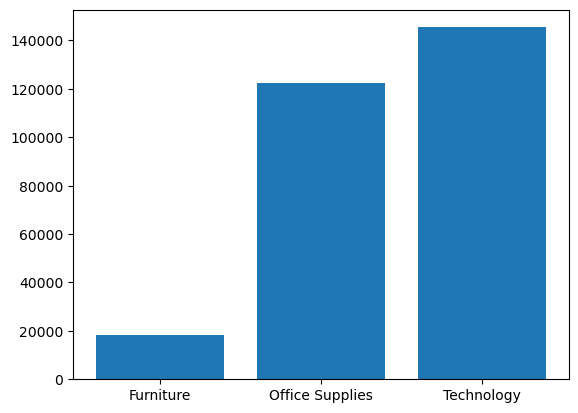

In [17]:
plt.bar(x=df['Category'].unique(),height=TotalProfit)
plt.show()

Plot SALES over Time

In [19]:
df['Order Month'] = df['Order Date'].dt.month

In [22]:
sales_over_time = df.groupby('Order Month')['Sales'].sum()
profit_over_time = df.groupby('Order Month')['Profit'].sum()
print(sales_over_time),print(profit_over_time)

Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64
Order Month
1      9134.4461
2     10294.6107
3     28594.6872
4     11587.4363
5     22411.3078
6     21285.7954
7     13832.6648
8     21776.9384
9     36857.4753
10    31784.0413
11    35468.4265
12    43369.1919
Name: Profit, dtype: float64


(None, None)

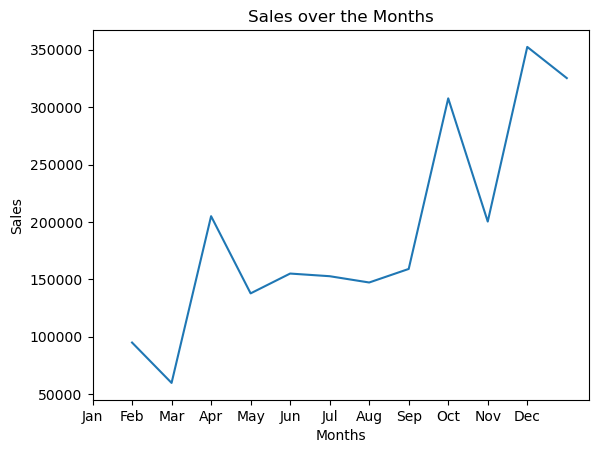

In [31]:
labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.plot(sales_over_time)
plt.title('Sales over the Months')
plt.xlabel('Months')
plt.xticks(ticks=range(len(labels)), labels=labels)
plt.ylabel('Sales')
plt.show()


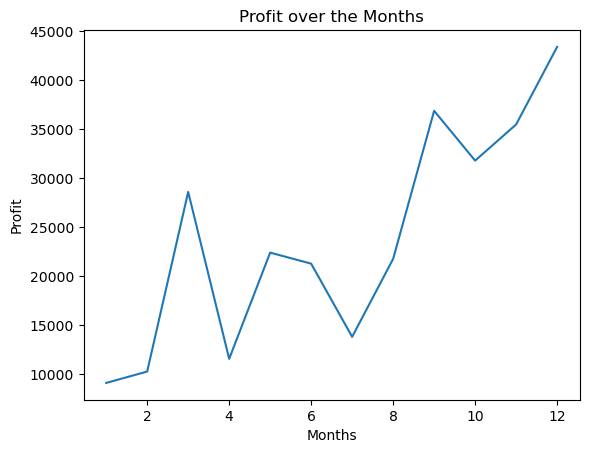

In [25]:
plt.plot(profit_over_time)
plt.title('Profit over the Months')
plt.xlabel('Months')
plt.ylabel('Profit')
plt.show()

Correlation Heatmap

In [32]:
columns = ['Sales','Quantity','Discount','Profit']
correlation_matrix = df[columns].corr()
print(correlation_matrix)

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


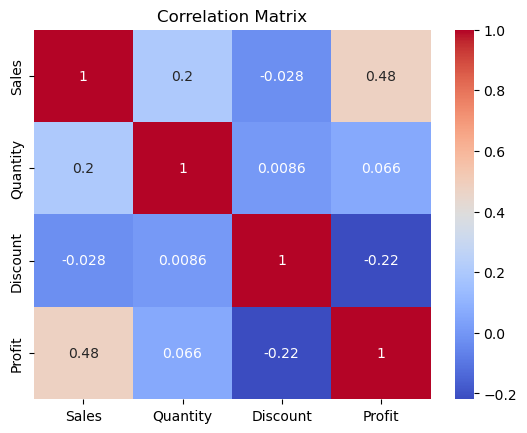

In [34]:
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Deepen Analysis

In [43]:
top5scbysales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
topscbyprofit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

In [44]:
bottom5scbysales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)
bottom5scbyprofit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True)

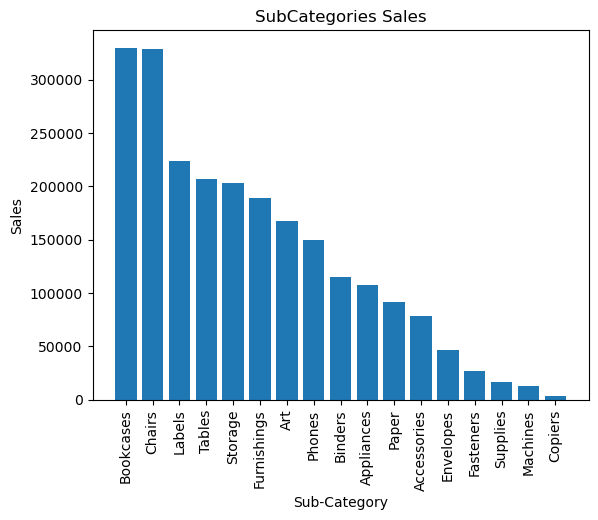

In [47]:
plt.bar(x=df['Sub-Category'].unique(),height=top5scbysales)
plt.title('SubCategories Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.show()

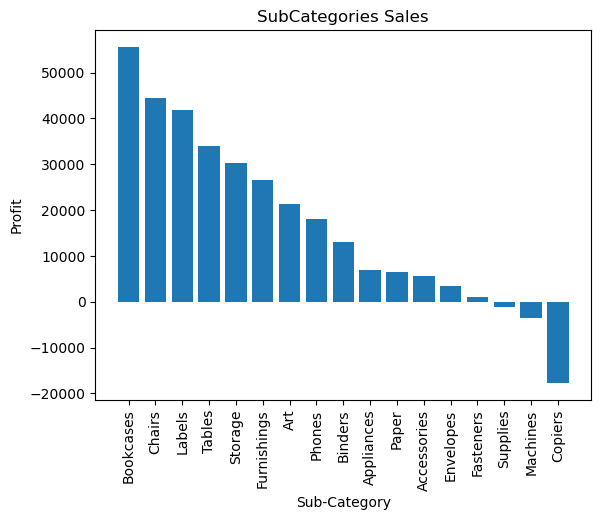

In [48]:
plt.bar(x=df['Sub-Category'].unique(),height=topscbyprofit)
plt.title('SubCategories Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.show()

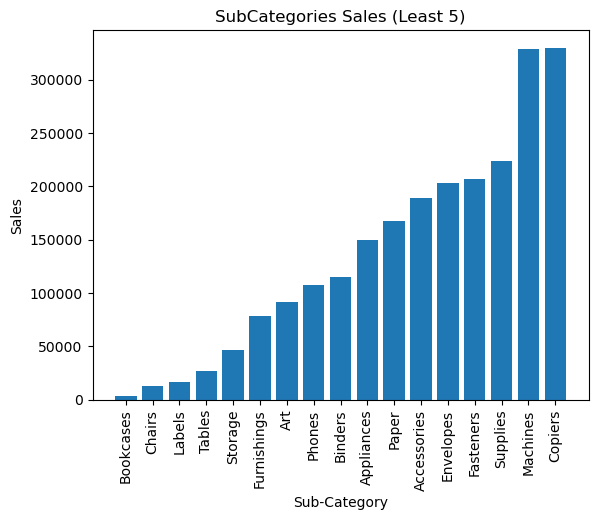

In [49]:
plt.bar(x=df['Sub-Category'].unique(),height=bottom5scbysales)
plt.title('SubCategories Sales (Least 5)')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.show()

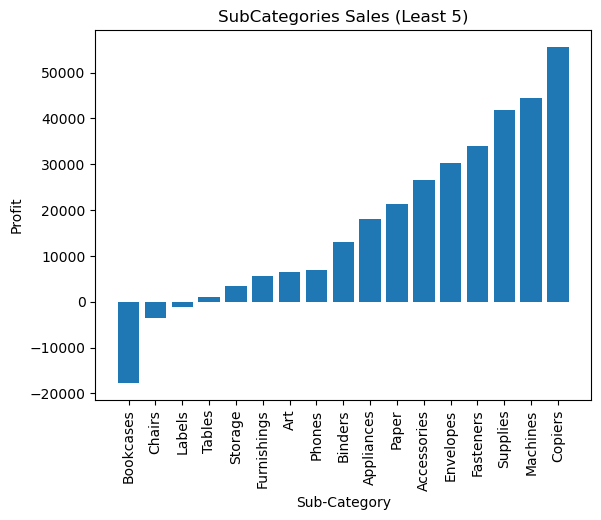

In [50]:
plt.bar(x=df['Sub-Category'].unique(),height=bottom5scbyprofit)
plt.title('SubCategories Sales (Least 5)')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.show()

Impact of Shipping Modes

In [52]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [53]:
sales_over_shipmode = df.groupby('Ship Mode')['Sales'].sum()
profit_over_shipmode = df.groupby('Ship Mode')['Profit'].sum()
print(sales_over_shipmode),print(profit_over_shipmode)

Ship Mode
First Class       3.514284e+05
Same Day          1.283631e+05
Second Class      4.591936e+05
Standard Class    1.358216e+06
Name: Sales, dtype: float64
Ship Mode
First Class        48969.8399
Same Day           15891.7589
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64


(None, None)

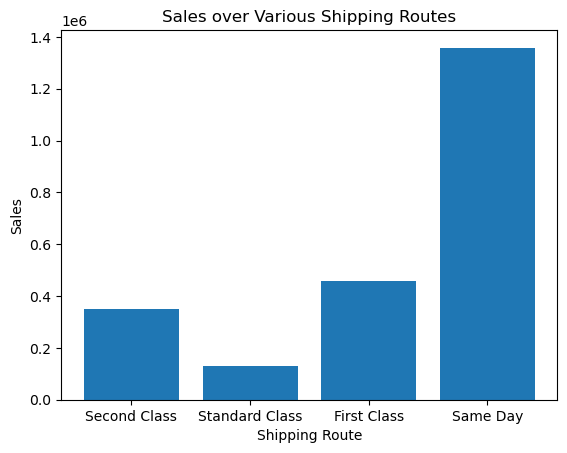

In [55]:
plt.bar(x=df['Ship Mode'].unique(),height=sales_over_shipmode)
plt.title('Sales over Various Shipping Routes')
plt.xlabel('Shipping Route')
plt.ylabel('Sales')
plt.show()

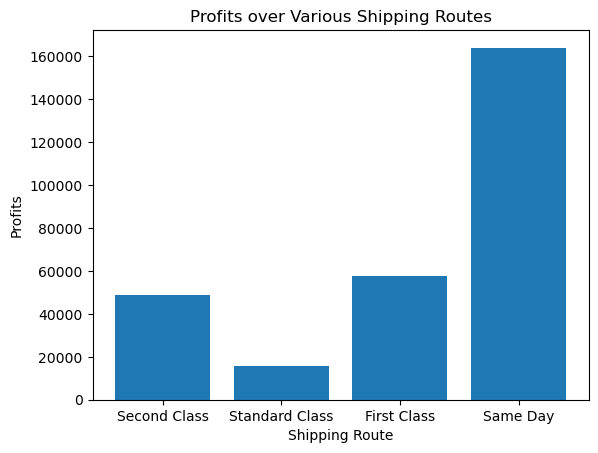

In [56]:
plt.bar(x=df['Ship Mode'].unique(),height=profit_over_shipmode)
plt.title('Profits over Various Shipping Routes')
plt.xlabel('Shipping Route')
plt.ylabel('Profits')
plt.show()

Inference from the Visualizations about Shipping Routes
1) Orders that are Completed the same day are the ones that bring the most revenue
2) First Class Shipping Routes are traditonally the most trusted method of Shipping

In [57]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Month'],
      dtype='object')

In [58]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [63]:
segmented_sales = df.groupby('Segment')['Sales'].mean()
segmented_profits = df.groupby('Segment')['Sales'].mean()
print(segmented_sales),print(segmented_profits)

Segment
Consumer       223.733644
Corporate      233.823300
Home Office    240.972041
Name: Sales, dtype: float64
Segment
Consumer       223.733644
Corporate      233.823300
Home Office    240.972041
Name: Sales, dtype: float64


(None, None)

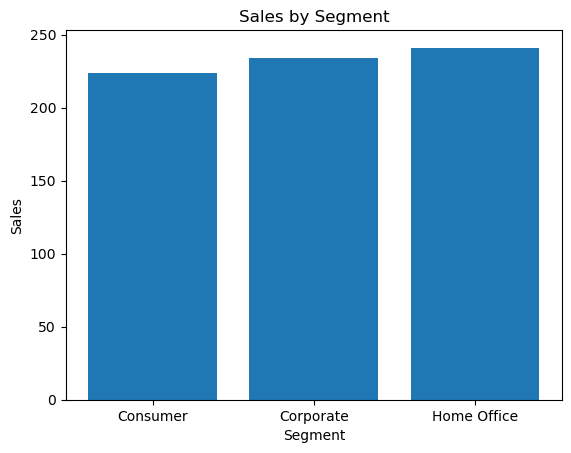

In [64]:
plt.bar(x=df['Segment'].unique(),height=segmented_sales)
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.title('Sales by Segment')
plt.show()


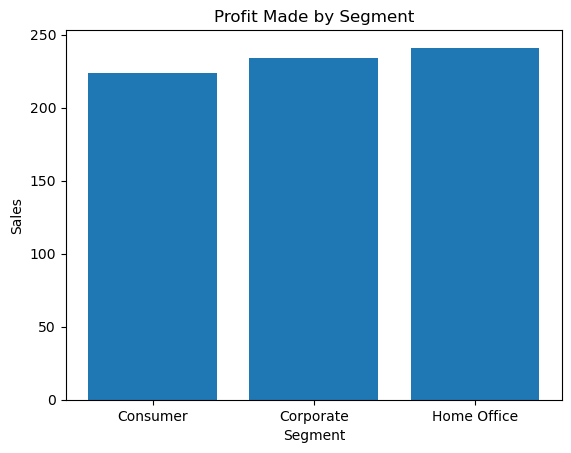

In [65]:
plt.bar(x=df['Segment'].unique(),height=segmented_profits)
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.title('Profit Made by Segment')
plt.show()

Inference from the Segment Visualizations:
1) The Avg Sales and Profit made by the Home Office Segment is the Most followed by Coporate Segment and Consumers.

Marketing Strategy

In [67]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Month'],
      dtype='object')

In [68]:
df[['Discount','Sales','Profit']]

,Discount,Sales,Profit
0,0.00,261.9600,41.9136
1,0.00,731.9400,219.5820
2,0.00,14.6200,6.8714
3,0.45,957.5775,-383.0310
4,0.20,22.3680,2.5164
...,...,...,...
9989,0.20,25.2480,4.1028
9990,0.00,91.9600,15.6332
9991,0.20,258.5760,19.3932
9992,0.00,29.6000,13.3200


In [72]:
dailydiscountedsales = df.groupby(['Order Date','Discount'])['Sales'].sum().unstack()
print(dailydiscountedsales)

Discount       0.00  0.10  0.15     0.20     0.30     0.32     0.40  0.45  \
Order Date                                                                  
2014-01-03      NaN   NaN   NaN   16.448      NaN      NaN      NaN   NaN   
2014-01-04      NaN   NaN   NaN  284.520      NaN      NaN      NaN   NaN   
2014-01-05      NaN   NaN   NaN   19.536      NaN      NaN      NaN   NaN   
2014-01-06  4407.10   NaN   NaN      NaN      NaN      NaN      NaN   NaN   
2014-01-07      NaN   NaN   NaN      NaN      NaN      NaN      NaN   NaN   
...             ...   ...   ...      ...      ...      ...      ...   ...   
2017-12-26   795.43   NaN   NaN   16.032      NaN      NaN      NaN   NaN   
2017-12-27      NaN   NaN   NaN   13.248      NaN      NaN  164.388   NaN   
2017-12-28   985.41   NaN   NaN  465.920  113.372  78.8528      NaN   NaN   
2017-12-29  2219.59   NaN   NaN  695.944      NaN      NaN      NaN   NaN   
2017-12-30   300.23   NaN   NaN  413.560      NaN      NaN      NaN   NaN   

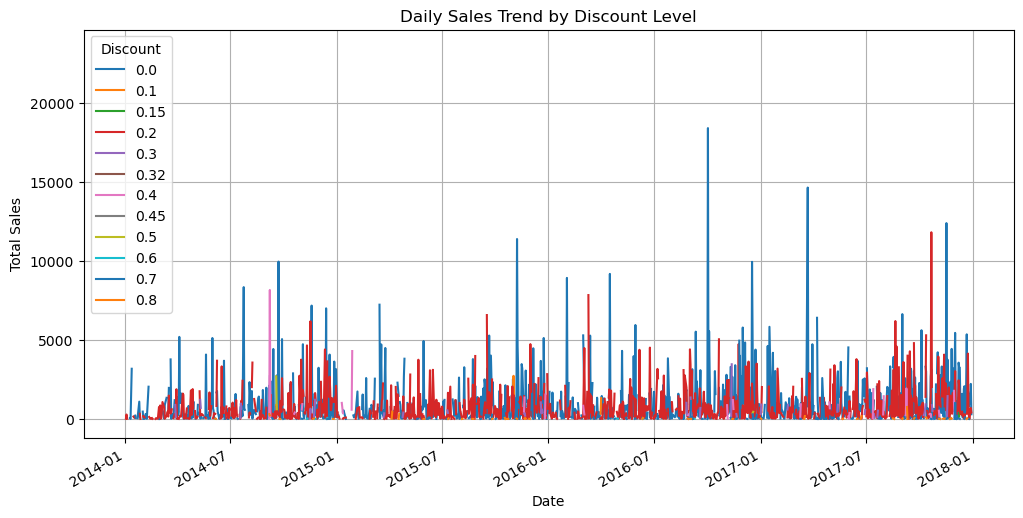

In [73]:
dailydiscountedsales.plot(figsize=(12,6))
plt.title("Daily Sales Trend by Discount Level")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title="Discount")
plt.grid(True)
plt.show()

In [75]:
dailydiscountedprofits = df.groupby(['Order Date','Discount'])['Profit'].sum().unstack()
print(dailydiscountedprofits)

Discount         0.00  0.10  0.15     0.20    0.30    0.32     0.40  0.45  \
Order Date                                                                  
2014-01-03        NaN   NaN   NaN   5.5512     NaN     NaN      NaN   NaN   
2014-01-04        NaN   NaN   NaN -60.5031     NaN     NaN      NaN   NaN   
2014-01-05        NaN   NaN   NaN   4.8840     NaN     NaN      NaN   NaN   
2014-01-06  1358.0524   NaN   NaN      NaN     NaN     NaN      NaN   NaN   
2014-01-07        NaN   NaN   NaN      NaN     NaN     NaN      NaN   NaN   
...               ...   ...   ...      ...     ...     ...      ...   ...   
2017-12-26    58.1190   NaN   NaN   5.6112     NaN     NaN      NaN   NaN   
2017-12-27        NaN   NaN   NaN   3.6432     NaN     NaN -35.6174   NaN   
2017-12-28   308.5122   NaN   NaN -33.0838 -3.2392 -11.596      NaN   NaN   
2017-12-29   666.0320   NaN   NaN -21.5982     NaN     NaN      NaN   NaN   
2017-12-30    59.2389   NaN   NaN  42.2976     NaN     NaN      NaN   NaN   

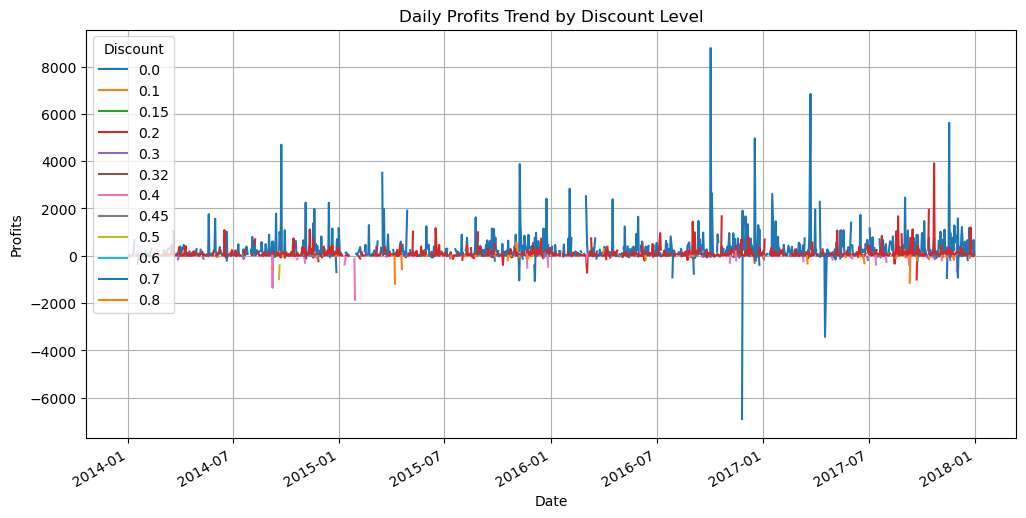

In [76]:
dailydiscountedprofits.plot(figsize=(12,6))
plt.title("Daily Profits Trend by Discount Level")
plt.xlabel("Date")
plt.ylabel("Profits")
plt.legend(title="Discount")
plt.grid(True)
plt.show()

In [78]:
daily_discount_sales = df.groupby(['Order Date', 'Discount'])['Sales'].sum().reset_index()
daily_discount_profits = df.groupby(['Order Date', 'Discount'])['Profit'].sum().reset_index()

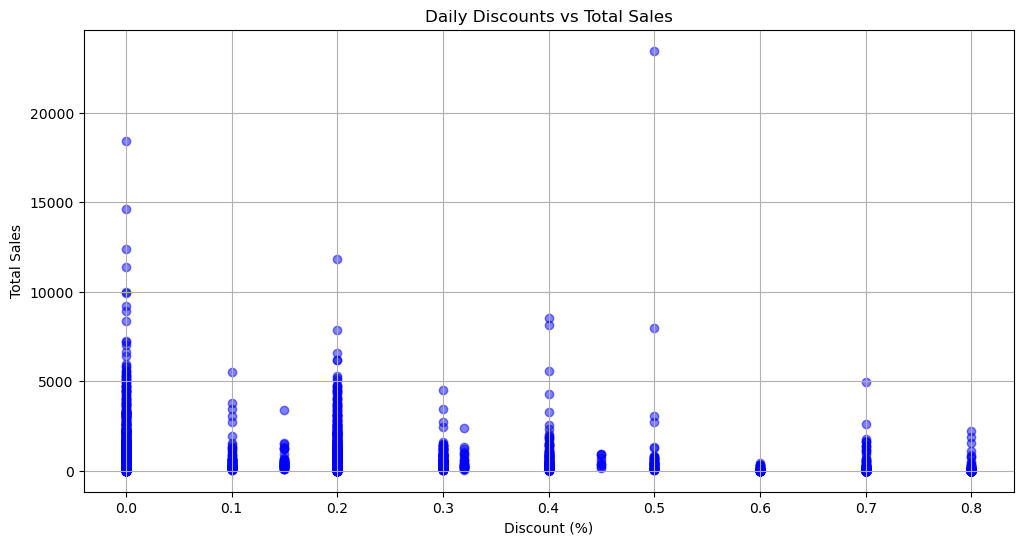

In [79]:
plt.figure(figsize=(12,6))
plt.scatter(daily_discount_sales['Discount'], daily_discount_sales['Sales'], alpha=0.5, color='blue')
plt.title('Daily Discounts vs Total Sales')
plt.xlabel('Discount (%)')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

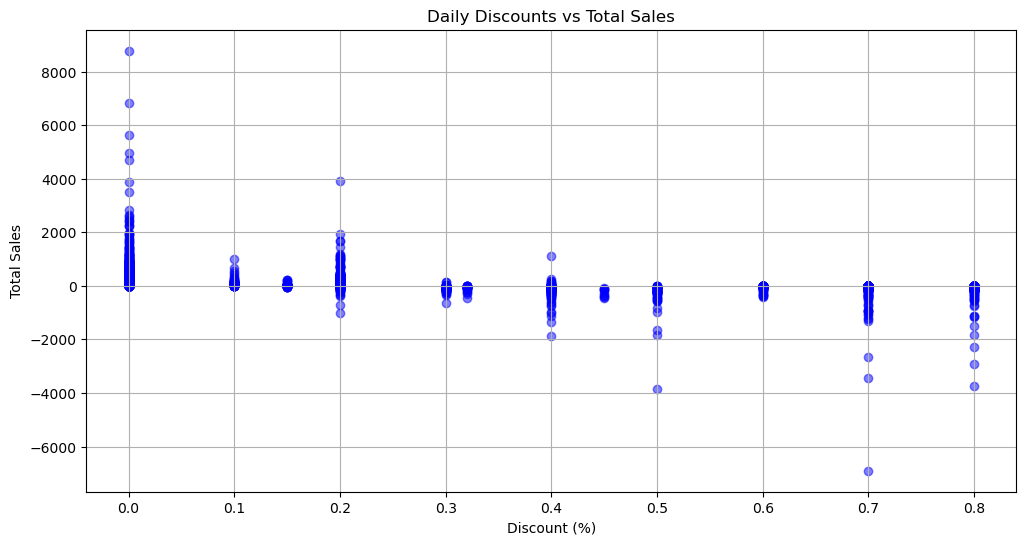

In [81]:
plt.figure(figsize=(12,6))
plt.scatter(daily_discount_profits['Discount'], daily_discount_profits['Profit'], alpha=0.5, color='blue')
plt.title('Daily Discounts vs Total Sales')
plt.xlabel('Discount (%)')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [82]:
correlation_discountsales = daily_discount_sales[['Discount','Sales']].corr().iloc[0,1]
correlation_discountprofits = daily_discount_profits[['Discount','Profit']].corr().iloc[0,1]
print(f"Correlation between Discount and Sales: {correlation_discountsales:.4f}")
print(f"Correlation between Discount and Profit: {correlation_discountprofits:.4f}")

Correlation between Discount and Sales: -0.2501
Correlation between Discount and Profit: -0.3485


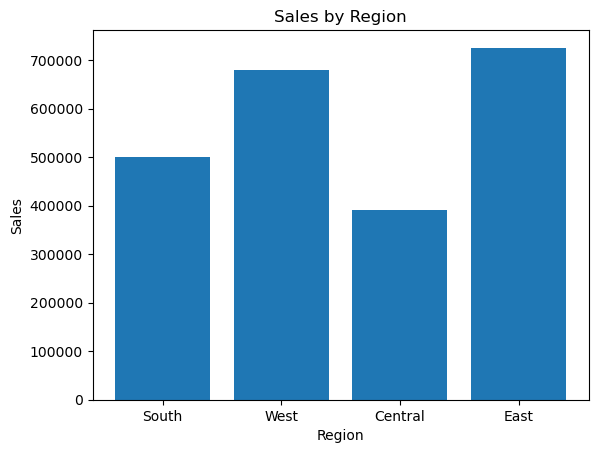

In [84]:
regionalsales = df.groupby('Region')['Sales'].sum()
plt.bar(x=df['Region'].unique(),height=regionalsales)
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales by Region')
plt.show()
